# Intrinsic Image Vulnerability Profile

Instead of analyzing the models or the attack algorithms, this notebook analyzes the dataset. 

By leveraging the instance-level raw data (`robustness_metrics_raw.csv`), we can investigate if certain images are inherently more susceptible to adversarial perturbations than others.

Every image in our dataset was attacked 15 times (3 models $\times$ 5 attacks). We will calculate a "Vulnerability Score" for each image based on how many times it was successfully perturbed, and plot the distribution. This helps identify if robustness is purely a model feature, or if it is also heavily dependent on the specific geometric and textural features of the input image.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the raw instance-level metrics
try:
    df_raw = pd.read_csv('robustness_metrics_raw.csv')
except FileNotFoundError:
    print("Error: 'robustness_metrics_raw.csv' not found. Please ensure the evaluation loop saved this file.")

# Filter out the Baseline
df_attacks = df_raw[df_raw['Attack'] != 'Baseline'].copy()

# Group by Image_ID to calculate the Vulnerability Score
image_vulnerability = df_attacks.groupby('Image_ID')['Is_Success'].sum().reset_index()
image_vulnerability.rename(columns={'Is_Success': 'Vulnerability_Score'}, inplace=True)

# Vulnerability Score = Total number of successful attacks across all models and algorithms
# Max possible score = 3 models * 5 attacks = 15

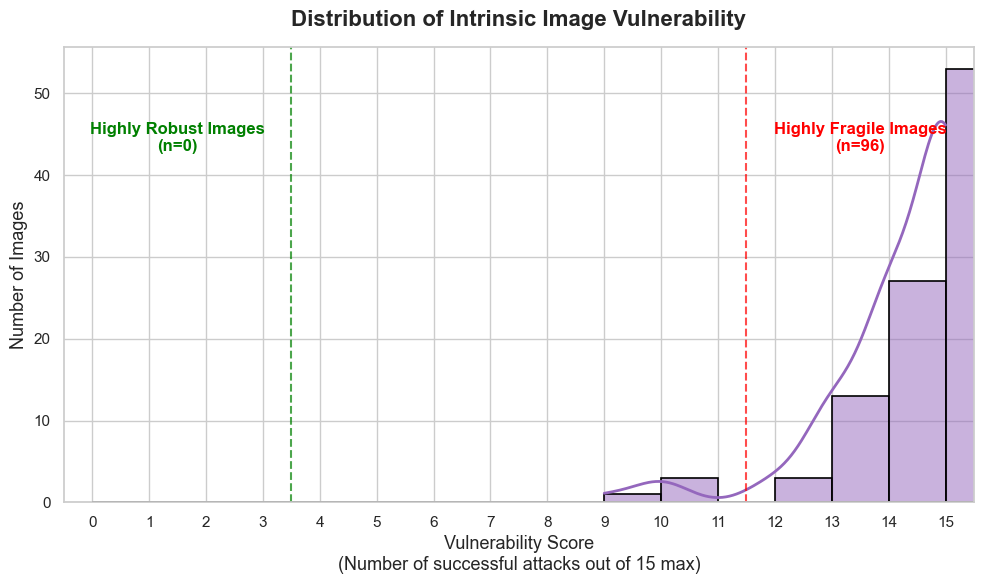

In [3]:
# Plotting the Distribution
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Histogram with KDE
sns.histplot(data=image_vulnerability, x='Vulnerability_Score', 
             bins=16, binrange=(0, 16), 
             color='#9467bd', edgecolor='black', linewidth=1.2,
             kde=True, line_kws={'linewidth': 2})

# Formatting
plt.title('Distribution of Intrinsic Image Vulnerability', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Vulnerability Score\n(Number of successful attacks out of 15 max)', fontsize=13)
plt.ylabel('Number of Images', fontsize=13)
plt.xticks(range(0, 16))
plt.xlim(-0.5, 15.5)

# Add annotations for extremes
robust_count = len(image_vulnerability[image_vulnerability['Vulnerability_Score'] <= 3])
fragile_count = len(image_vulnerability[image_vulnerability['Vulnerability_Score'] >= 12])

plt.axvline(x=3.5, color='green', linestyle='--', alpha=0.7)
plt.text(1.5, plt.ylim()[1]*0.8, f'Highly Robust Images\n(n={robust_count})', 
         color='green', ha='center', va='center', fontweight='bold')

plt.axvline(x=11.5, color='red', linestyle='--', alpha=0.7)
plt.text(13.5, plt.ylim()[1]*0.8, f'Highly Fragile Images\n(n={fragile_count})', 
         color='red', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
# Print Insights
print("=== VULNERABILITY INSIGHTS ===")
print(f"Average Vulnerability Score: {image_vulnerability['Vulnerability_Score'].mean():.2f} / 15")
print(f"Images that resisted EVERYTHING (Score 0): {len(image_vulnerability[image_vulnerability['Vulnerability_Score'] == 0])}")
print(f"Images that failed EVERY time (Score 15): {len(image_vulnerability[image_vulnerability['Vulnerability_Score'] == 15])}")

=== VULNERABILITY INSIGHTS ===
Average Vulnerability Score: 14.17 / 15
Images that resisted EVERYTHING (Score 0): 0
Images that failed EVERY time (Score 15): 53
